In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

In [ ]:
# read dataset from a public Google Drive File

file_link = 'https://drive.google.com/file/d/1-xGWT6TnsMd5JLGeIQlgP-V1nrfWTFD7/view?usp=sharing'

# get the id part of the file
id = file_link.split("/")[-2]

# creating a new link using the id for better readability of csv file in pandas
new_link = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(new_link)

# let's look at the first few instances
df.head()


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN
3,412802,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63,NaN
4,412803,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00,NaN


In [ ]:

df = df.drop_duplicates()
df

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN
3,412802,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63,NaN
4,412803,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
18857,165993,375,Nitrogen dioxide (NO2),Mean,ppb,CD,207,Kingsbridge Heights and Bedford (CD7),Winter 2012-13,12/01/2012,25.78,NaN
18858,338255,386,Ozone (O3),Mean,ppb,CD,107,Upper West Side (CD7),Summer 2015,06/01/2015,28.13,NaN
18859,651029,386,Ozone (O3),Mean,ppb,CD,307,Sunset Park (CD7),Summer 2019,06/01/2019,28.78,NaN
18860,667628,375,Nitrogen dioxide (NO2),Mean,ppb,CD,207,Kingsbridge Heights and Bedford (CD7),Winter 2019-20,12/01/2019,23.68,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


In [ ]:
df.nunique()

,0
Unique ID,18862
Indicator ID,21
Name,18
Measure,8
Measure Info,8
Geo Type Name,5
Geo Join ID,72
Geo Place Name,114
Time Period,57
Start_Date,46


In [ ]:
df.isnull().sum()

,0
Unique ID,0
Indicator ID,0
Name,0
Measure,0
Measure Info,0
Geo Type Name,0
Geo Join ID,0
Geo Place Name,0
Time Period,0
Start_Date,0


In [ ]:

df = df.drop(['Unique ID'], axis=1)
df = df.drop(['Message'], axis=1)
df = df.drop(['Indicator ID'], axis=1)
df = df.drop(['Geo Type Name'], axis=1)
df = df.drop(['Geo Join ID'], axis=1)
df


,Name,Measure,Measure Info,Geo Place Name,Time Period,Start_Date,Data Value
0,Nitrogen dioxide (NO2),Mean,ppb,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97
1,Nitrogen dioxide (NO2),Mean,ppb,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42
2,Nitrogen dioxide (NO2),Mean,ppb,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55
3,Nitrogen dioxide (NO2),Mean,ppb,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63
4,Nitrogen dioxide (NO2),Mean,ppb,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00
...,...,...,...,...,...,...,...
18857,Nitrogen dioxide (NO2),Mean,ppb,Kingsbridge Heights and Bedford (CD7),Winter 2012-13,12/01/2012,25.78
18858,Ozone (O3),Mean,ppb,Upper West Side (CD7),Summer 2015,06/01/2015,28.13
18859,Ozone (O3),Mean,ppb,Sunset Park (CD7),Summer 2019,06/01/2019,28.78
18860,Nitrogen dioxide (NO2),Mean,ppb,Kingsbridge Heights and Bedford (CD7),Winter 2019-20,12/01/2019,23.68


In [ ]:
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['Name', 'Measure', 'Measure Info', 'Geo Place Name', 'Time Period', 'Start_Date']
Numerical Variables:
['Data Value']


In [ ]:
for i in cat_cols:
  print(f'{i} values:')
  print(df[i].unique())
  print('#########################################################')

Name values:
['Nitrogen dioxide (NO2)' 'Fine particles (PM 2.5)'
 'Boiler Emissions- Total SO2 Emissions' 'Ozone (O3)'
 'Asthma emergency department visits due to PM2.5'
 'Annual vehicle miles traveled'
 'Respiratory hospitalizations due to PM2.5 (age 20+)'
 'Asthma hospitalizations due to Ozone'
 'Boiler Emissions- Total NOx Emissions'
 'Boiler Emissions- Total PM2.5 Emissions'
 'Outdoor Air Toxics - Formaldehyde' 'Outdoor Air Toxics - Benzene'
 'Asthma emergency departments visits due to Ozone'
 'Annual vehicle miles traveled (cars)'
 'Annual vehicle miles traveled (trucks)'
 'Cardiovascular hospitalizations due to PM2.5 (age 40+)'
 'Deaths due to PM2.5' 'Cardiac and respiratory deaths due to Ozone']
#########################################################
Measure values:
['Mean' 'Number per km2' 'Estimated annual rate (age 18+)' 'Million miles'
 'Estimated annual rate' 'Estimated annual rate (under age 18)'
 'Annual average concentration' 'Estimated annual rate (age 30+)']
########

In [ ]:
df.describe(include='all')

,Name,Measure,Measure Info,Geo Place Name,Time Period,Start_Date,Data Value
count,18862,18862,18862,18862,18862,18862,18862.000000
unique,18,8,8,114,57,46,NaN
top,Nitrogen dioxide (NO2),Mean,ppb,Williamsburg - Bushwick,2009-2011,01/01/2015,NaN
freq,6345,14805,8460,281,480,906,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,21.051580
std,NaN,NaN,NaN,NaN,NaN,NaN,23.564920
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,8.742004
50%,NaN,NaN,NaN,NaN,NaN,NaN,14.790000
75%,NaN,NaN,NaN,NaN,NaN,NaN,26.267500


In [ ]:
feats=['Nitrogen dioxide (NO2)','Fine particles (PM 2.5)','Boiler Emissions- Total SO2 Emissions','Ozone (O3)','Boiler Emissions- Total NOx Emissions','Boiler Emissions- Total PM2.5 Emissions','Outdoor Air Toxics - Formaldehyde','Outdoor Air Toxics - Benzene']
new_df = df[df['Name'].isin(feats)].copy()
df=new_df
df

,Name,Measure,Measure Info,Geo Place Name,Time Period,Start_Date,Data Value
0,Nitrogen dioxide (NO2),Mean,ppb,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97
1,Nitrogen dioxide (NO2),Mean,ppb,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42
2,Nitrogen dioxide (NO2),Mean,ppb,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55
3,Nitrogen dioxide (NO2),Mean,ppb,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63
4,Nitrogen dioxide (NO2),Mean,ppb,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00
...,...,...,...,...,...,...,...
18857,Nitrogen dioxide (NO2),Mean,ppb,Kingsbridge Heights and Bedford (CD7),Winter 2012-13,12/01/2012,25.78
18858,Ozone (O3),Mean,ppb,Upper West Side (CD7),Summer 2015,06/01/2015,28.13
18859,Ozone (O3),Mean,ppb,Sunset Park (CD7),Summer 2019,06/01/2019,28.78
18860,Nitrogen dioxide (NO2),Mean,ppb,Kingsbridge Heights and Bedford (CD7),Winter 2019-20,12/01/2019,23.68


/tmp/ipython-input-365381188.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.groupby([pd.Grouper(key="Start_Date", freq="M"), "Name"])["Data Value"].mean().reset_index()


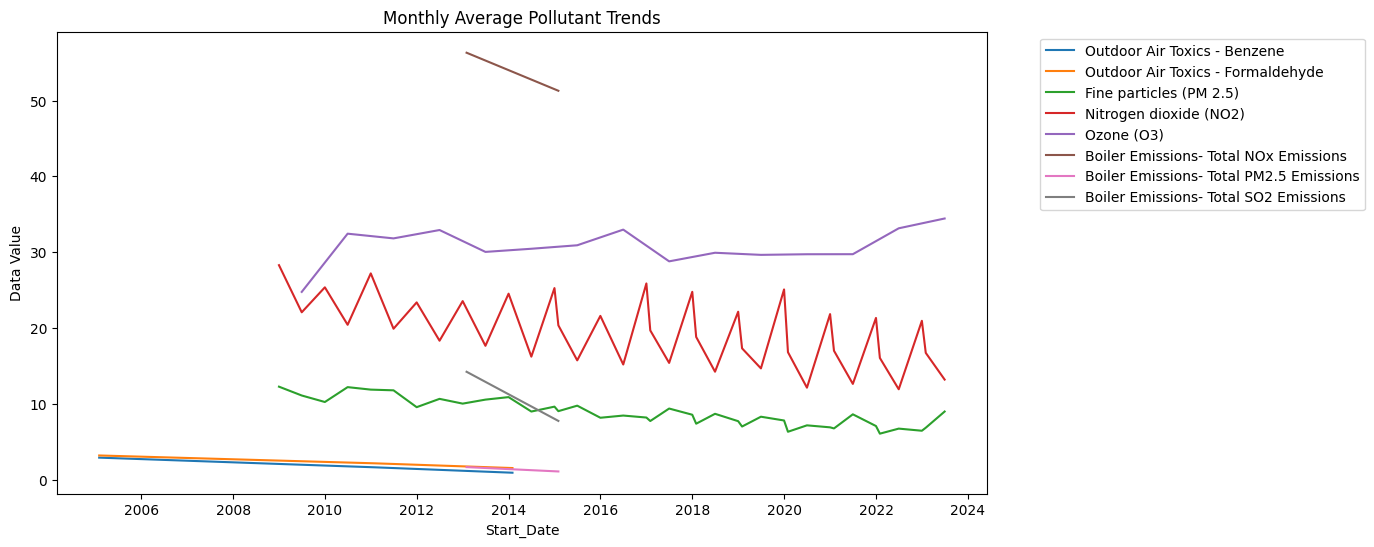

In [ ]:
df["Start_Date"] = pd.to_datetime(df["Start_Date"])
df_monthly = df.groupby([pd.Grouper(key="Start_Date", freq="M"), "Name"])["Data Value"].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x="Start_Date", y="Data Value", hue="Name", data=df_monthly)
plt.title("Monthly Average Pollutant Trends")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
df_ts=df.pivot_table(index=['Geo Place Name','Start_Date'],columns='Name', values='Data Value').reset_index()
df_ts

Name,Geo Place Name,Start_Date,Boiler Emissions- Total NOx Emissions,Boiler Emissions- Total PM2.5 Emissions,Boiler Emissions- Total SO2 Emissions,Fine particles (PM 2.5),Nitrogen dioxide (NO2),Outdoor Air Toxics - Benzene,Outdoor Air Toxics - Formaldehyde,Ozone (O3)
0,Bay Ridge and Dyker Heights (CD10),2008-12-01,NaN,NaN,NaN,11.220000,25.985000,NaN,NaN,NaN
1,Bay Ridge and Dyker Heights (CD10),2009-06-01,NaN,NaN,NaN,10.770000,20.380000,NaN,NaN,25.560000
2,Bay Ridge and Dyker Heights (CD10),2009-12-01,NaN,NaN,NaN,9.590000,24.700000,NaN,NaN,NaN
3,Bay Ridge and Dyker Heights (CD10),2010-06-01,NaN,NaN,NaN,11.740000,18.080000,NaN,NaN,33.440000
4,Bay Ridge and Dyker Heights (CD10),2010-12-01,NaN,NaN,NaN,11.235000,26.040000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4692,Woodside and Sunnyside (CD2),2022-01-01,NaN,NaN,NaN,6.451912,18.413673,NaN,NaN,NaN
4693,Woodside and Sunnyside (CD2),2022-06-01,NaN,NaN,NaN,7.248774,14.180812,NaN,NaN,32.765812
4694,Woodside and Sunnyside (CD2),2022-12-01,NaN,NaN,NaN,6.954335,23.736379,NaN,NaN,NaN
4695,Woodside and Sunnyside (CD2),2023-01-01,NaN,NaN,NaN,7.395583,19.858310,NaN,NaN,NaN


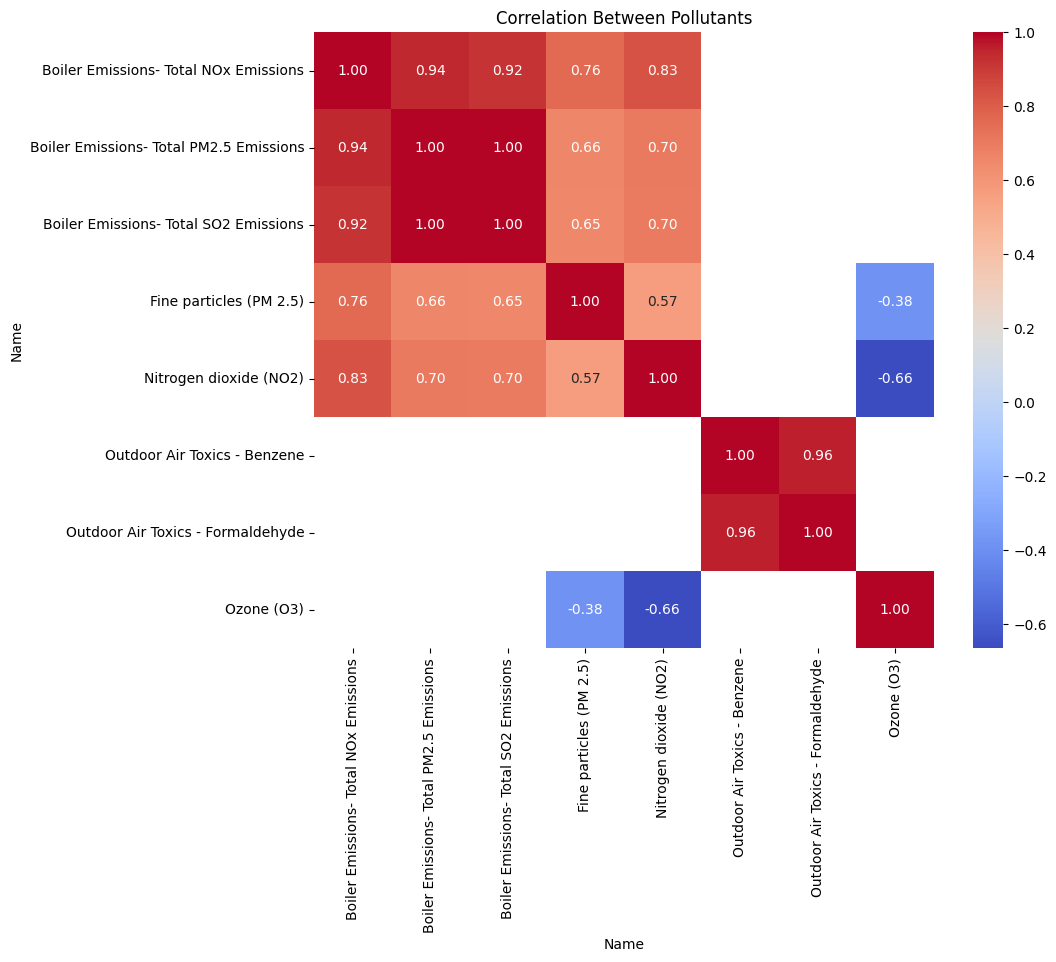

In [ ]:
df_pivot = df.pivot_table(index=["Geo Place Name","Start_Date"], columns="Name", values="Data Value")
plt.figure(figsize=(10,8))
sns.heatmap(df_pivot.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Pollutants")
plt.show()

In [ ]:
df_ts = df_ts.sort_values(by=["Geo Place Name", "Start_Date"])
df_ts

Name,Geo Place Name,Start_Date,Boiler Emissions- Total NOx Emissions,Boiler Emissions- Total PM2.5 Emissions,Boiler Emissions- Total SO2 Emissions,Fine particles (PM 2.5),Nitrogen dioxide (NO2),Outdoor Air Toxics - Benzene,Outdoor Air Toxics - Formaldehyde,Ozone (O3)
0,Bay Ridge and Dyker Heights (CD10),2008-12-01,NaN,NaN,NaN,11.220000,25.985000,NaN,NaN,NaN
1,Bay Ridge and Dyker Heights (CD10),2009-06-01,NaN,NaN,NaN,10.770000,20.380000,NaN,NaN,25.560000
2,Bay Ridge and Dyker Heights (CD10),2009-12-01,NaN,NaN,NaN,9.590000,24.700000,NaN,NaN,NaN
3,Bay Ridge and Dyker Heights (CD10),2010-06-01,NaN,NaN,NaN,11.740000,18.080000,NaN,NaN,33.440000
4,Bay Ridge and Dyker Heights (CD10),2010-12-01,NaN,NaN,NaN,11.235000,26.040000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4692,Woodside and Sunnyside (CD2),2022-01-01,NaN,NaN,NaN,6.451912,18.413673,NaN,NaN,NaN
4693,Woodside and Sunnyside (CD2),2022-06-01,NaN,NaN,NaN,7.248774,14.180812,NaN,NaN,32.765812
4694,Woodside and Sunnyside (CD2),2022-12-01,NaN,NaN,NaN,6.954335,23.736379,NaN,NaN,NaN
4695,Woodside and Sunnyside (CD2),2023-01-01,NaN,NaN,NaN,7.395583,19.858310,NaN,NaN,NaN


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
import xgboost as xgb

# --- Start: Re-introducing df definition and preprocessing steps ---
file_link = 'https://drive.google.com/file/d/1-xGWT6TnsMd5JLGeIQlgP-V1nrfWTFD7/view?usp=sharing'
id = file_link.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(new_link)

df = df.drop_duplicates()
df = df.drop(['Unique ID', 'Message', 'Indicator ID', 'Geo Type Name', 'Geo Join ID'], axis=1)
# --- End: Re-introducing df definition and preprocessing steps ---


feats = ['Nitrogen dioxide (NO2)', 'Fine particles (PM 2.5)', 'Boiler Emissions- Total SO2 Emissions',
         'Ozone (O3)', 'Boiler Emissions- Total NOx Emissions', 'Boiler Emissions- Total PM2.5 Emissions',
         'Outdoor Air Toxics - Formaldehyde', 'Outdoor Air Toxics - Benzene']

new_df = df[df['Name'].isin(feats)].copy()
df = new_df
df_ts = df.pivot_table(index=['Geo Place Name', 'Start_Date'], columns='Name', values='Data Value').reset_index()
df_ts = df_ts.sort_values(by=["Geo Place Name", "Start_Date"])
available_feats = [c for c in feats if c in df_ts.columns]

df_shifted = df_ts.copy()
for col in available_feats:
    df_shifted[col + "_target"] = df_shifted.groupby("Geo Place Name")[col].shift(-1)

target_cols = [c + "_target" for c in available_feats if c + "_target" in df_shifted.columns]

# Feature engineering: Add lag features and rolling statistics
for col in available_feats:
    df_shifted[f'{col}_lag1'] = df_shifted.groupby("Geo Place Name")[col].shift(1)
    df_shifted[f'{col}_lag2'] = df_shifted.groupby("Geo Place Name")[col].shift(2)
    df_shifted[f'{col}_rolling_mean_3'] = df_shifted.groupby("Geo Place Name")[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean())
    df_shifted[f'{col}_rolling_std_3'] = df_shifted.groupby("Geo Place Name")[col].transform(
        lambda x: x.rolling(window=3, min_periods=1).std())

# Add temporal features
df_shifted['Start_Date'] = pd.to_datetime(df_shifted['Start_Date'])
df_shifted['month'] = df_shifted['Start_Date'].dt.month
df_shifted['quarter'] = df_shifted['Start_Date'].dt.quarter
df_shifted['year'] = df_shifted['Start_Date'].dt.year

# Prepare features for modeling
all_features = available_feats + [f'{col}_lag1' for col in available_feats] + \
               [f'{col}_lag2' for col in available_feats] + \
               [f'{col}_rolling_mean_3' for col in available_feats] + \
               [f'{col}_rolling_std_3' for col in available_feats] + \
               ['month', 'quarter', 'year']

# Remove any features that might not exist due to NaN issues
all_features = [f for f in all_features if f in df_shifted.columns]

numeric_cols = df_shifted.select_dtypes(include=np.number).columns.tolist()
df_model_imputed = df_shifted.fillna(df_shifted[numeric_cols].mean())

X = df_model_imputed[all_features].values
Y = df_model_imputed[target_cols].values

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, shuffle=False, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


models = {
    "SVR": MultiOutputRegressor(SVR(kernel='rbf', C=100, gamma=0.01, epsilon=0.1)),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8)),
    "Random Forest": MultiOutputRegressor(
        RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)),
    "XGBoost": MultiOutputRegressor(
        xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8))
}


results = {}
for name, model in models.items():
        if name in ["SVR", "MLP"]:
            model.fit(X_train_scaled, Y_train)
            Y_pred = model.predict(X_test_scaled)

        else:
            model.fit(X_train, Y_train)
            Y_pred = model.predict(X_test)

        mse = mean_squared_error(Y_test, Y_pred)
        r2 = r2_score(Y_test, Y_pred, multioutput='uniform_average')

        cv_scores = cross_val_score(model, X_train, Y_train, cv=5,
                                      scoring='neg_mean_squared_error')
        cv_mse = -cv_scores.mean()
        results[name] = {
            "MSE": mse,
            "R2": r2,
            "CV_MSE": cv_mse if cv_mse else "N/A"
        }

        print(f"{name}: MSE = {mse:.4f}, R² = {r2:.4f}")

SVR: MSE = 13.1838, R² = 0.5978
Gradient Boosting: MSE = 8.9359, R² = 0.8170
Random Forest: MSE = 9.4164, R² = 0.7883
XGBoost: MSE = 12.2549, R² = 0.7666
